## Lab 2
### Part 2: Dealing with overfitting

Today we work with [Fashion-MNIST dataset](https://github.com/zalandoresearch/fashion-mnist) (*hint: it is available in `torchvision`*).

Your goal for today:
1. Train a FC (fully-connected) network that achieves >= 0.885 test accuracy.
2. Cause considerable overfitting by modifying the network (e.g. increasing the number of network parameters and/or layers) and demonstrate in in the appropriate way (e.g. plot loss and accurasy on train and validation set w.r.t. network complexity).
3. Try to deal with overfitting (at least partially) by using regularization techniques (Dropout/Batchnorm/...) and demonstrate the results.

__Please, write a small report describing your ideas, tries and achieved results in the end of this file.__

*Note*: Tasks 2 and 3 are interrelated, in task 3 your goal is to make the network from task 2 less prone to overfitting. Task 1 is independent from 2 and 3.

*Note 2*: We recomment to use Google Colab or other machine with GPU acceleration.

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchsummary
from IPython.display import clear_output
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
import os


device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [2]:
# Technical function
def mkdir(path):
    if not os.path.exists(root_path):
        os.mkdir(root_path)
        print('Directory', path, 'is created!')
    else:
        print('Directory', path, 'already exists!')
        
root_path = 'fmnist'
mkdir(root_path)

Directory fmnist is created!


In [3]:
download = True
train_transform = transforms.ToTensor()
test_transform = transforms.ToTensor()
transforms.Compose((transforms.ToTensor()))


fmnist_dataset_train = torchvision.datasets.FashionMNIST(root_path, 
                                                        train=True, 
                                                        transform=train_transform,
                                                        target_transform=None,
                                                        download=download)
fmnist_dataset_test = torchvision.datasets.FashionMNIST(root_path, 
                                                       train=False, 
                                                       transform=test_transform,
                                                       target_transform=None,
                                                       download=download)

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 272kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.09MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.2MB/s]


In [ ]:
train_loader = torch.utils.data.DataLoader(fmnist_dataset_train, 
                                           batch_size=128,
                                           shuffle=True,
                                           num_workers=2)
test_loader = torch.utils.data.DataLoader(fmnist_dataset_test,
                                          batch_size=256,
                                          shuffle=False,
                                          num_workers=2)

In [ ]:
len(fmnist_dataset_test)

10000

In [6]:
for img, label in train_loader:
    print(img.shape)
    # print(img)
    print(label.shape)
    print(label.size(0))
    break

torch.Size([128, 1, 28, 28])
torch.Size([128])
128


### Task 1
Train a network that achieves $\geq 0.885$ test accuracy. It's fine to use only Linear (`nn.Linear`) layers and activations/dropout/batchnorm. Convolutional layers might be a great use, but we will meet them a bit later.

In [ ]:
class TinyNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), # This layer converts image into a vector to use Linear layers afterwards
            # Your network structure comes here  

            nn.Linear(input_shape, input_shape // 2),
            nn.BatchNorm1d(input_shape // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2731),

            nn.Linear(input_shape // 2, input_shape // 4),
            nn.BatchNorm1d(input_shape // 4),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2731),

            nn.Linear(input_shape // 4, num_classes)
            )
        
    def forward(self, inp):       
        out = self.model(inp)
        return out

In [ ]:
torchsummary.summary(TinyNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 392]         307,720
       BatchNorm1d-3                  [-1, 392]             784
              ReLU-4                  [-1, 392]               0
           Dropout-5                  [-1, 392]               0
            Linear-6                  [-1, 196]          77,028
       BatchNorm1d-7                  [-1, 196]             392
              ReLU-8                  [-1, 196]               0
           Dropout-9                  [-1, 196]               0
           Linear-10                   [-1, 10]           1,970
Total params: 387,894
Trainable params: 387,894
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 1.48
Estimated T

Your experiments come here:

In [9]:
from sklearn.metrics import accuracy_score

model = TinyNeuralNetwork().to(device)
opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
loss_func = nn.CrossEntropyLoss()

n_epoch = 10

for epoch in range(n_epoch):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        opt.zero_grad()

        outputs = model(xb)
        loss = loss_func(outputs, yb)
        loss.backward()

        opt.step()

        running_loss += loss.item() * xb.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)

    model.eval()
    running_val_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            outputs = model(xb)
            loss = loss_func(outputs, yb)
            running_val_loss += loss.item() * xb.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(yb.cpu().numpy())

    epoch_val_loss = running_val_loss / len(test_loader.dataset)
    val_acc = accuracy_score(all_targets, all_preds)

    print(f"Epoch {epoch+1}/{n_epoch}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {val_acc:.4f}")


Epoch 1/10, Train Loss: 0.5350, Val Loss: 0.4219, Val Acc: 0.8424
Epoch 2/10, Train Loss: 0.3922, Val Loss: 0.3768, Val Acc: 0.8576
Epoch 3/10, Train Loss: 0.3571, Val Loss: 0.3545, Val Acc: 0.8709
Epoch 4/10, Train Loss: 0.3336, Val Loss: 0.3392, Val Acc: 0.8763
Epoch 5/10, Train Loss: 0.3149, Val Loss: 0.3326, Val Acc: 0.8794
Epoch 6/10, Train Loss: 0.3009, Val Loss: 0.3268, Val Acc: 0.8833
Epoch 7/10, Train Loss: 0.2904, Val Loss: 0.3279, Val Acc: 0.8767
Epoch 8/10, Train Loss: 0.2811, Val Loss: 0.3228, Val Acc: 0.8846
Epoch 9/10, Train Loss: 0.2697, Val Loss: 0.3139, Val Acc: 0.8870
Epoch 10/10, Train Loss: 0.2609, Val Loss: 0.3097, Val Acc: 0.8898


### Task 2: Overfit it.
Build a network that will overfit to this dataset. Demonstrate the overfitting in the appropriate way (e.g. plot loss and accurasy on train and test set w.r.t. network complexity).

*Note:* you also might decrease the size of `train` dataset to enforce the overfitting and speed up the computations.

In [ ]:
class OverfittingNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(input_shape, input_shape // 2),
            nn.ReLU(inplace=True),

            nn.Linear(input_shape // 2, input_shape // 4),
            nn.ReLU(inplace=True),

            nn.Linear(input_shape // 4, input_shape // 8),
            nn.ReLU(inplace=True),

            nn.Linear(input_shape // 8, input_shape // 16),
            nn.ReLU(inplace=True),

            nn.Linear(input_shape // 16, num_classes)
        )
        
    def forward(self, inp):       
        out = self.model(inp)
        return out

In [11]:
torchsummary.summary(OverfittingNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 392]         307,720
              ReLU-3                  [-1, 392]               0
            Linear-4                  [-1, 196]          77,028
              ReLU-5                  [-1, 196]               0
            Linear-6                   [-1, 98]          19,306
              ReLU-7                   [-1, 98]               0
            Linear-8                   [-1, 49]           4,851
              ReLU-9                   [-1, 49]               0
           Linear-10                   [-1, 10]             500
Total params: 409,405
Trainable params: 409,405
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 1.56
Estimated T

In [12]:
model = OverfittingNeuralNetwork().to(device)
opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
loss_func = nn.CrossEntropyLoss()

epoch_train_loss_list = []
epoch_val_loss_list = []
val_acc_list = []
n_epoch = 100

for epoch in range(n_epoch):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        opt.zero_grad()
        outputs = model(xb)

        loss = loss_func(outputs, yb)
        loss.backward()
        opt.step()

        running_loss += loss.item() * xb.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)

    model.eval()
    running_val_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            outputs = model(xb)

            loss = loss_func(outputs, yb)
            running_val_loss += loss.item() * xb.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(yb.cpu().numpy())

        epoch_val_loss = running_val_loss / len(test_loader.dataset)
        val_acc = accuracy_score(all_targets, all_preds)

        print(f"Epoch {epoch+1}/{n_epoch}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {val_acc:.4f}")

        epoch_train_loss_list.append(epoch_train_loss)
        epoch_val_loss_list.append(epoch_val_loss)
        val_acc_list.append(val_acc)

Epoch 1/100, Train Loss: 1.2427, Val Loss: 0.6356, Val Acc: 0.7787
Epoch 2/100, Train Loss: 0.5498, Val Loss: 0.5420, Val Acc: 0.8010
Epoch 3/100, Train Loss: 0.4555, Val Loss: 0.4442, Val Acc: 0.8381
Epoch 4/100, Train Loss: 0.3975, Val Loss: 0.4586, Val Acc: 0.8266
Epoch 5/100, Train Loss: 0.3660, Val Loss: 0.3809, Val Acc: 0.8630
Epoch 6/100, Train Loss: 0.3431, Val Loss: 0.3888, Val Acc: 0.8585
Epoch 7/100, Train Loss: 0.3222, Val Loss: 0.3778, Val Acc: 0.8648
Epoch 8/100, Train Loss: 0.3044, Val Loss: 0.3827, Val Acc: 0.8645
Epoch 9/100, Train Loss: 0.2913, Val Loss: 0.3590, Val Acc: 0.8730
Epoch 10/100, Train Loss: 0.2799, Val Loss: 0.3546, Val Acc: 0.8714
Epoch 11/100, Train Loss: 0.2746, Val Loss: 0.3516, Val Acc: 0.8764
Epoch 12/100, Train Loss: 0.2651, Val Loss: 0.3404, Val Acc: 0.8800
Epoch 13/100, Train Loss: 0.2535, Val Loss: 0.3563, Val Acc: 0.8738
Epoch 14/100, Train Loss: 0.2462, Val Loss: 0.3381, Val Acc: 0.8778
Epoch 15/100, Train Loss: 0.2420, Val Loss: 0.3873, Val A

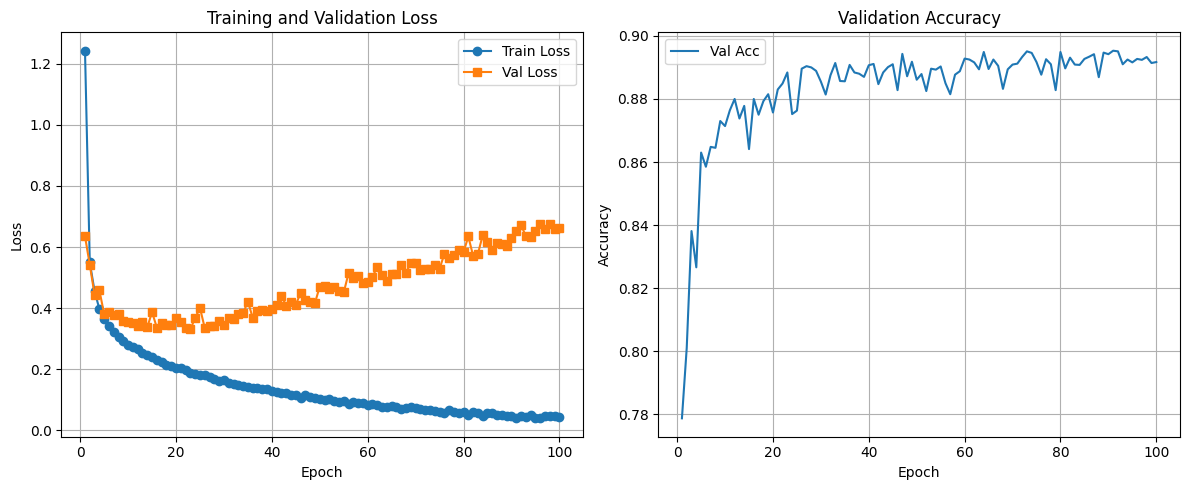

In [13]:
# Построение графиков потерь
plt.figure(figsize=(12, 5))

# График 1: Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, n_epoch+1), epoch_train_loss_list, label='Train Loss', marker='o')
plt.plot(range(1, n_epoch+1), epoch_val_loss_list, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epoch+1), val_acc_list, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Task 3: Fix it.
Fix the overfitted network from the previous step (at least partially) by using regularization techniques (Dropout/Batchnorm/...) and demonstrate the results. 

In [17]:
class FixedNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_shape, input_shape // 2),
            nn.BatchNorm1d(input_shape // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2731),

            nn.Linear(input_shape // 2, input_shape // 4),
            nn.BatchNorm1d(input_shape // 4),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2731),

            nn.Linear(input_shape // 4, input_shape // 8),
            nn.BatchNorm1d(input_shape // 8),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2731),

            nn.Linear(input_shape // 8, input_shape // 16),
            nn.BatchNorm1d(input_shape // 16),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2731),

            nn.Linear(input_shape // 16, num_classes)
        )
        
    def forward(self, inp):       
        out = self.model(inp)
        return out

In [18]:
torchsummary.summary(FixedNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 392]         307,720
       BatchNorm1d-3                  [-1, 392]             784
              ReLU-4                  [-1, 392]               0
           Dropout-5                  [-1, 392]               0
            Linear-6                  [-1, 196]          77,028
       BatchNorm1d-7                  [-1, 196]             392
              ReLU-8                  [-1, 196]               0
           Dropout-9                  [-1, 196]               0
           Linear-10                   [-1, 98]          19,306
      BatchNorm1d-11                   [-1, 98]             196
             ReLU-12                   [-1, 98]               0
          Dropout-13                   [-1, 98]               0
           Linear-14                   

In [19]:
model = FixedNeuralNetwork().to(device)
opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
loss_func = nn.CrossEntropyLoss()

n_epoch = 100
epoch_train_loss_list_fixed = []
epoch_val_loss_list_fixed = []
val_acc_list_fixed = []

for epoch in range(n_epoch):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        opt.zero_grad()

        outputs = model(xb)
        loss = loss_func(outputs, yb)
        loss.backward()

        opt.step()

        running_loss += loss.item() * xb.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)

    model.eval()
    running_val_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            outputs = model(xb)
            loss = loss_func(outputs, yb)
            running_val_loss += loss.item() * xb.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(yb.cpu().numpy())

        epoch_val_loss = running_val_loss / len(test_loader.dataset)
        val_acc = accuracy_score(all_targets, all_preds)

        print(f"Epoch {epoch+1}/{n_epoch}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {val_acc:.4f}")

        epoch_train_loss_list_fixed.append(epoch_train_loss)
        epoch_val_loss_list_fixed.append(epoch_val_loss)
        val_acc_list_fixed.append(val_acc)

Epoch 1/100, Train Loss: 0.7098, Val Loss: 0.4532, Val Acc: 0.8354
Epoch 2/100, Train Loss: 0.4706, Val Loss: 0.3983, Val Acc: 0.8568
Epoch 3/100, Train Loss: 0.4283, Val Loss: 0.3731, Val Acc: 0.8661
Epoch 4/100, Train Loss: 0.4011, Val Loss: 0.3679, Val Acc: 0.8665
Epoch 5/100, Train Loss: 0.3816, Val Loss: 0.3572, Val Acc: 0.8689
Epoch 6/100, Train Loss: 0.3662, Val Loss: 0.3548, Val Acc: 0.8761
Epoch 7/100, Train Loss: 0.3525, Val Loss: 0.3406, Val Acc: 0.8773
Epoch 8/100, Train Loss: 0.3435, Val Loss: 0.3450, Val Acc: 0.8718
Epoch 9/100, Train Loss: 0.3320, Val Loss: 0.3303, Val Acc: 0.8825
Epoch 10/100, Train Loss: 0.3272, Val Loss: 0.3315, Val Acc: 0.8792
Epoch 11/100, Train Loss: 0.3150, Val Loss: 0.3273, Val Acc: 0.8841
Epoch 12/100, Train Loss: 0.3074, Val Loss: 0.3180, Val Acc: 0.8844
Epoch 13/100, Train Loss: 0.3028, Val Loss: 0.3650, Val Acc: 0.8697
Epoch 14/100, Train Loss: 0.2960, Val Loss: 0.3211, Val Acc: 0.8868
Epoch 15/100, Train Loss: 0.2922, Val Loss: 0.3293, Val A

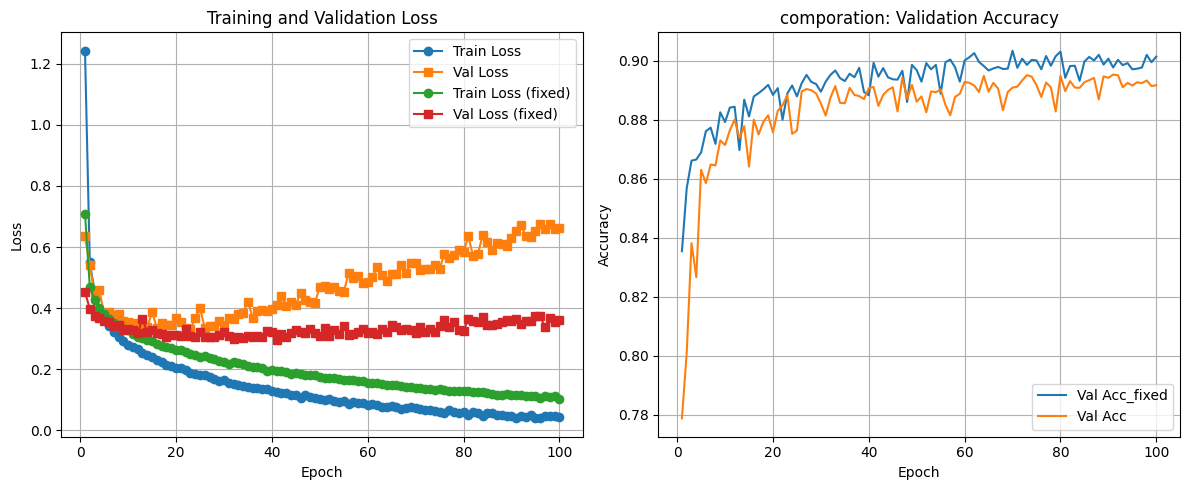

In [30]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epoch+1), epoch_train_loss_list, label='Train Loss', marker='o')
plt.plot(range(1, n_epoch+1), epoch_val_loss_list, label='Val Loss', marker='s')
plt.plot(range(1, n_epoch+1), epoch_train_loss_list_fixed, label='Train Loss (fixed)', marker='o')
plt.plot(range(1, n_epoch+1), epoch_val_loss_list_fixed, label='Val Loss (fixed)', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epoch+1), val_acc_list_fixed, label='Val Acc_fixed')
plt.plot(range(1, n_epoch+1), val_acc_list, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('comporation: Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [31]:
print("epoch_train_loss_list_fixed[39] == ", epoch_train_loss_list_fixed[39])
print("epoch_train_loss_list[19] == ", epoch_train_loss_list[19])
print("max_accuracy == ", max(val_acc_list[15:25]))
print("max_accuracy_fixed == ", max(val_acc_list_fixed[35:45]))

epoch_train_loss_list_fixed[39] ==  0.19855772884686787
epoch_train_loss_list[19] ==  0.20450532026290894
max_accuracy ==  0.8884
max_accuracy_fixed ==  0.8993


### Conclusions:
_Write down small report with your conclusions and your ideas._

To sum up:

Addition Dropout and BatchNormalization provide shift in the number of epochs for retraining (20 -> 40), validation loss decrease in graphics, but train loss increase. Max accuracy improved (0.8884 -> 0.8993)